<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1169798/3381162928.py:67: SyntaxWarning: invalid escape sequence '\h'
  math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)
/tmp/ipykernel_1169798/3381162928.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_1169798/3381162928.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_1169798/3381162928.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_1169798/3381162928.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_

Fitted parameters: alpha = 1.000000, beta = 1.000000
Fitted parameters: alpha = 0.979560, beta = 1.000000
Fitted parameters: alpha = 0.959112, beta = 1.000000
Fitted parameters: alpha = 0.938452, beta = 1.000000
Fitted parameters: alpha = 0.917719, beta = 1.000000
Fitted parameters: alpha = 0.896858, beta = 1.000000


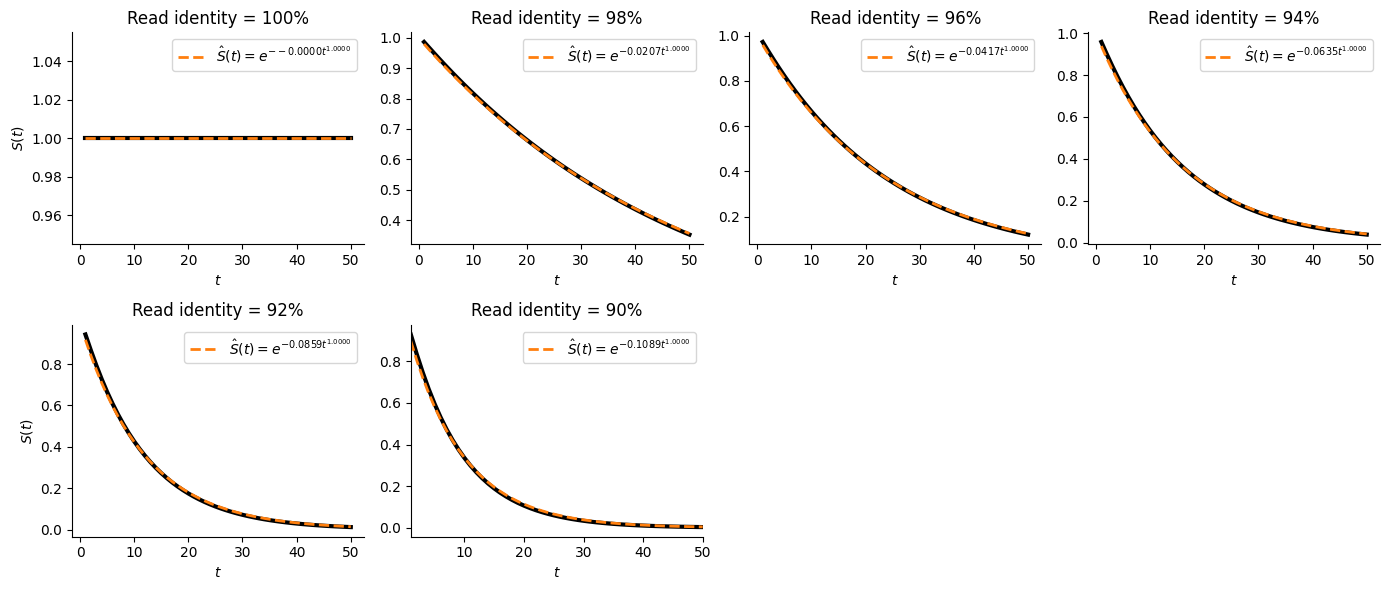

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns


# Define the function to fit
def fit_function_constant(i, alpha, beta):
    return np.exp(- alpha - beta * i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean * i + (std ** 2) * (i ** 2) / 2)

def fit_function_discrete_weibull(i, l, k):
    return l ** ((i) ** 1)


kmer_hit_rate_csv = [
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_100.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_98.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_96.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_94.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_92.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_90.matched_kmers.csv",
]

labels = [
    "Read identity = 100%",
    "Read identity = 98%",
    "Read identity = 96%",
    "Read identity = 94%",
    "Read identity = 92%",
    "Read identity = 90%"
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(1, 51)
hazard_ratio_estimate_range = range(1, 51)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

ground_truth_survival_rates = []


func = fit_function_discrete_weibull
#func = fit_function_constant

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    
    survival_rates_esimates = survival_rates[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    ground_truth_survival_rates.append(survival_rates_esimates)
    survival_rates_plot = survival_rates[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")
    l = -np.log(alpha)

    math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)

    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, survival_rates_plot, linewidth=3, color='black')
    fitted_hazard_ratios = [func(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linewidth=2, linestyle='--', label=math_label, color='C1')
    
    axes[i].tick_params(axis='both')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$t$')
    if i % 4 == 0:
        axes[i].set_ylabel('$S(t)$')
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.show()
#plt.ylim(0, 0.05)

In [2]:
ground_truth_survival_rates

[array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([0.98631223, 0.96629815, 0.94654502, 0.92710994, 0.90802711,
        0.88931466, 0.87097674, 0.85300804, 0.83540321, 0.8181551 ,
        0.80125557, 0.78469787, 0.76847555, 0.7525826 , 0.73701029,
        0.72175363, 0.70680663, 0.692163  , 0.67781574, 0.66375934,
        0.64998884, 0.63649767, 0.6232808 , 0.61033417, 0.59765083,
        0.58522566, 0.57305357, 0.56113155, 0.54945199, 0.5380105 ,
        0.52680185, 0.51582173, 0.50506661, 0.49453065, 0.48421007,
        0.47409966, 0.46419626, 0.45449549, 0.44499256, 0.43568391,
        0.42656595, 0.41763515, 0.40888681, 0.40031755, 0.39192487,
        0.38370523, 0.37565441, 0.36776904, 0.36004581, 0.35248147]),
 array([0.97240902, 0.933105  , 0.89488257, 0.85795698, 0.82242334,
        0.78830129, 0.75

In [8]:
import pandas as pd
import glob

output_dir="../../output/coverage_dependence"
prefix = "Ecoli_K12_MG1655"

id = [100, 98, 96, 94, 92, 90]
cov = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Initialize list to store results as a df
identity = []
coverage = []
lambda_estimates = []
beta_estimates = []
coverage_estimates = []
with_reference = []

for i in id:
    for c in cov:
        a_list = []
        b_list = []
        coverage_list = []
        
        output_file_name = f"{output_dir}/{prefix}_depth_{c}_id_{i}_exp_[0-9+].csv"
        output_file_ref_name = f"{output_dir}/{prefix}_depth_{c}_id_{i}_exp_[0-9+]_ref.csv"
        all_files = glob.glob(output_file_name)
        for file in all_files:
            df = pd.read_csv(file)


            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            coverage_estimates.append(df['true_median_coverage'].item())
            identity.append(i)
            coverage.append(c)
            with_reference.append('Without reference')
        
        all_files_ref = glob.glob(output_file_ref_name)
        for file in all_files_ref:
            df = pd.read_csv(file)

            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            coverage_estimates.append(df['true_median_coverage'].item())
            identity.append(i)
            coverage.append(c)
            with_reference.append('With reference')


In [9]:
result_df = pd.DataFrame({
    'identity': identity,
    'coverage': coverage,
    'lambda_estimate': lambda_estimates,
    'beta_estimate': beta_estimates,
    'coverage_estimate': coverage_estimates,
    'with_reference': with_reference
})

result_df['error_estimate'] = 1 - np.exp(-result_df['lambda_estimate'])

# Coverage at 100x

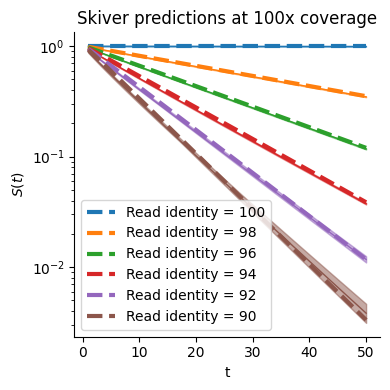

In [15]:
import seaborn as sns

result_df_100x = result_df[result_df['coverage'] == 100]
"""
sns.stripplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=True, alpha=.2, legend=False,
    palette=["indianred", "goldenrod"],
)
sns.pointplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=20, markeredgewidth=3,
    palette=["indianred", "goldenrod"],
)
"""
fig = plt.figure(figsize=(4, 4))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})

def weibull_parameter_to_hazard_rate(t_range, lambd, beta):
    res = []
    for t in t_range:
        res.append(1 - np.exp(-lambd * (t**beta - (t-1)**beta)))
    return res

def weibull_parameter_to_survival_rate(t_range, lambd, beta):
    res = []
    for t in t_range:
        res.append(np.exp(-lambd * (t ** beta)))
    return res

def survival_rates_to_hazard_rates(survival_rates):
    res = []
    for i in range(len(survival_rates)):
        if i == 0:
            res.append(1 - survival_rates[i])
        else:
            res.append(1 - survival_rates[i] / survival_rates[i-1])

def find_survival_rate_mre(survival_rates, lambd, beta):
    relative_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = np.exp(-lambd * (t ** beta))
        relative_error.append(np.abs(estimated_survival_rate - survival_rates[i]) / np.abs(survival_rates[i]))
    
    return np.mean(relative_error)



for i, identity in enumerate(id):
    # Plot the ground truth survival rate
    plt.plot(hazard_ratio_plot_range, ground_truth_survival_rates[i], color=f'C{i}', linestyle="--", linewidth=3, label=f"Read identity = {identity}")

    ground_truth_hazard_rate = survival_rates_to_hazard_rates(ground_truth_survival_rates)

    result_df_sub = result_df_100x[result_df_100x['identity'] == identity]
    predicted_survival_rates_list = []
    for j in range(len(result_df_sub)):
        # plot the multiple estimates
        lambd = result_df_sub.iloc[j]["lambda_estimate"].item()
        beta = result_df_sub.iloc[j]["beta_estimate"].item()
        predicted_survival_rates = np.array(weibull_parameter_to_survival_rate(hazard_ratio_plot_range, lambd, beta))
        #plt.plot(hazard_ratio_plot_range, predicted_survival_rates, color=f'C{i}', linewidth=1, alpha=0.2)

        predicted_survival_rates_list.append(predicted_survival_rates)
    
    # Calculate the mean/min/max predicted survival rates across all estimates
    mean_predicted_survival_rates = np.mean(predicted_survival_rates_list, axis=0)
    min_predicted_survival_rates = np.min(predicted_survival_rates_list, axis=0)
    max_predicted_survival_rates = np.max(predicted_survival_rates_list, axis=0)

    # Plot the mean predicted survival rates with a solid line and the min/max predicted survival rates with a shaded area
    plt.plot(hazard_ratio_plot_range, mean_predicted_survival_rates, color=f'C{i}', linewidth=1)
    plt.fill_between(hazard_ratio_plot_range, min_predicted_survival_rates, max_predicted_survival_rates, color=f'C{i}', alpha=0.5)



plt.yscale('log')
plt.xlabel("t")
plt.ylabel("$S(t)$")
plt.title("Skiver predictions at 100x coverage")
plt.tight_layout()
# Plot ground truth as a lineplot
#ground_truth_error = [1 - np.exp(-l) for l in ground_truth_lambda[::-1]]
#plt.plot(np.arange(len(ground_truth_lambda)), ground_truth_error, color='black', linestyle='--', marker='d', linewidth=3, label='Ground truth $h(1)$')
plt.legend()
plt.savefig("../../figures/simulated_data_error_rate.svg")



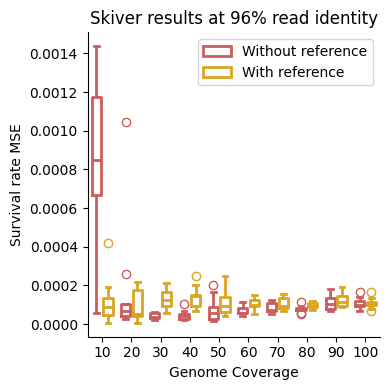

In [20]:
import seaborn as sns

def find_survival_rate_mise_weibull(survival_rates, lambd, beta):
    squared_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = np.exp(-lambd * (t ** beta))
        squared_error.append((estimated_survival_rate - survival_rates[i]) ** 2)
    
    return np.mean(squared_error)

def find_hazard_rate_mise_weibull(survival_rates, lambd, beta):
    # calculate ground truth hazard rate
    hazard_rates = []
    for i in range(len(survival_rates)):
        if i == 0:
            hazard_rates.append(1 - survival_rates[i])
        else:
            hazard_rates.append(1 - survival_rates[i] / survival_rates[i-1])
    
    squared_error = []
    for i in range(len(survival_rates)):
        t = i + 1
        estimated_hazard_rate = 1 - np.exp(- lambd * (t ** beta - (t-1) ** beta))
        squared_error.append((hazard_rates[i] - estimated_hazard_rate) ** 2)
    return np.mean(squared_error)

# Calculate hazard rate MISE and survival rate MISE for each estimate
hazard_rate_mise = []
survival_rate_mise = []

for i in range(len(result_df)):
    identity = result_df.iloc[i]['identity']
    identity_index = id.index(identity)
    hazard_rate_mise.append(find_hazard_rate_mise_weibull(ground_truth_survival_rates[identity_index], result_df.iloc[i]['lambda_estimate'], result_df.iloc[i]['beta_estimate']))
    survival_rate_mise.append(find_survival_rate_mise_weibull(ground_truth_survival_rates[identity_index], result_df.iloc[i]['lambda_estimate'], result_df.iloc[i]['beta_estimate']))

result_df['hazard_rate_mise'] = hazard_rate_mise
result_df['survival_rate_mise'] = survival_rate_mise



result_df_id = result_df[result_df['identity'] == 96]
"""
sns.stripplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=True, alpha=.2, legend=False,
    palette=["indianred", "goldenrod"],
)
sns.pointplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=20, markeredgewidth=3,
    palette=["indianred", "goldenrod"],
)
"""
fig = plt.figure(figsize=(4, 4))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})

sns.boxplot(
    data=result_df_id, x="coverage", y="survival_rate_mise", hue="with_reference",
    fill=False, gap=.2,
    linewidth=2,
    flierprops={"marker": "o"},
    palette=["indianred", "goldenrod"],
)
plt.xlabel("Genome Coverage")
plt.ylabel("Survival rate MSE")
plt.title("Skiver results at 96% read identity")

# Plot ground truth as a lineplot
#plt.plot(np.arange(len(ground_truth_lambda)), ground_truth_error, color='black', marker='d', linewidth=3, label='Ground truth error rate')
plt.legend()
plt.tight_layout()
plt.savefig("../../figures/simulated_data_coverage_dependence.svg")

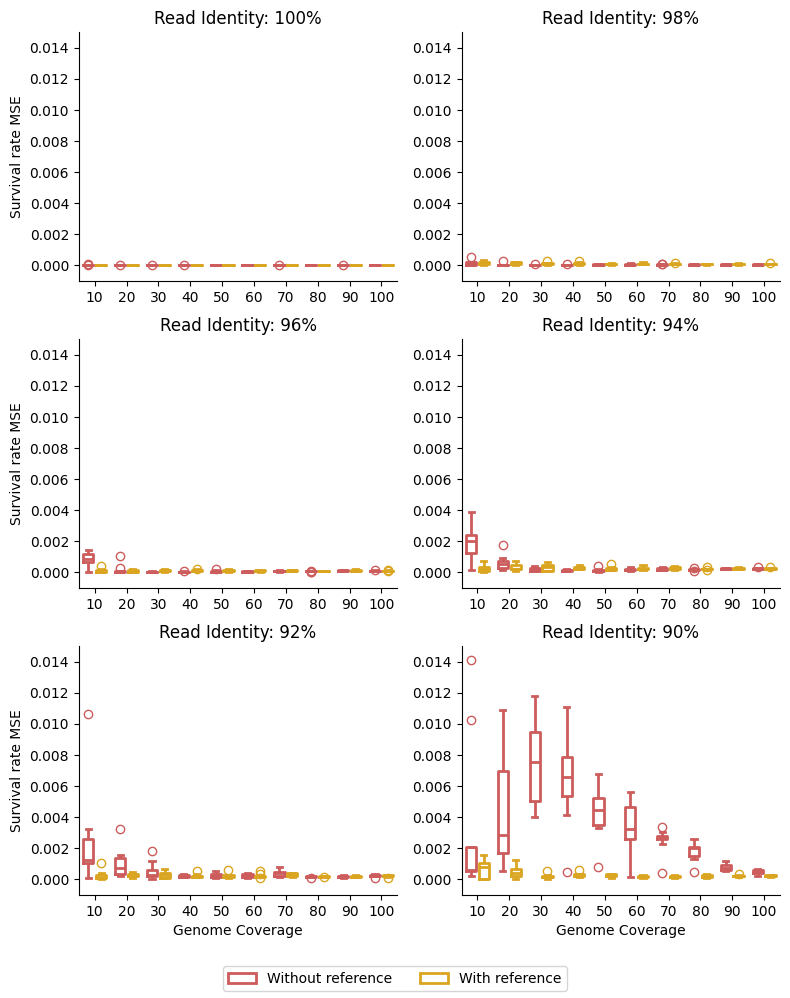

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten()

for idx, identity_value in enumerate(id):
    result_df_subset = result_df[result_df['identity'] == identity_value]
    sns.boxplot(
        data=result_df_subset, x="coverage", y="survival_rate_mise", hue="with_reference",
        fill=False, gap=.2,
        linewidth=2,
        flierprops={"marker": "o"},
        palette=["indianred", "goldenrod"],
        ax=axes[idx]
    )
    
    axes[idx].set_title(f"Read Identity: {identity_value}%")
    if idx >= 4:
        axes[idx].set_xlabel("Genome Coverage")
    else:
        axes[idx].set_xlabel("")
    if idx % 2 == 0:
        axes[idx].set_ylabel("Survival rate MSE")
    else:
        axes[idx].set_ylabel("")
    #axes[idx].set_ylim(max(-0.01, gt - 0.03), gt + 0.15)
    axes[idx].get_legend().remove()
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].set_ylim(-0.001, 0.015)

    #axes[idx].set_yscale('log')
    #axes[idx].legend(title="Reference", loc="upper right")
plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(bottom=0.1)

# Adjust layout

plt.savefig("../../figures/simulated_data_all_coverage_survival.pdf")


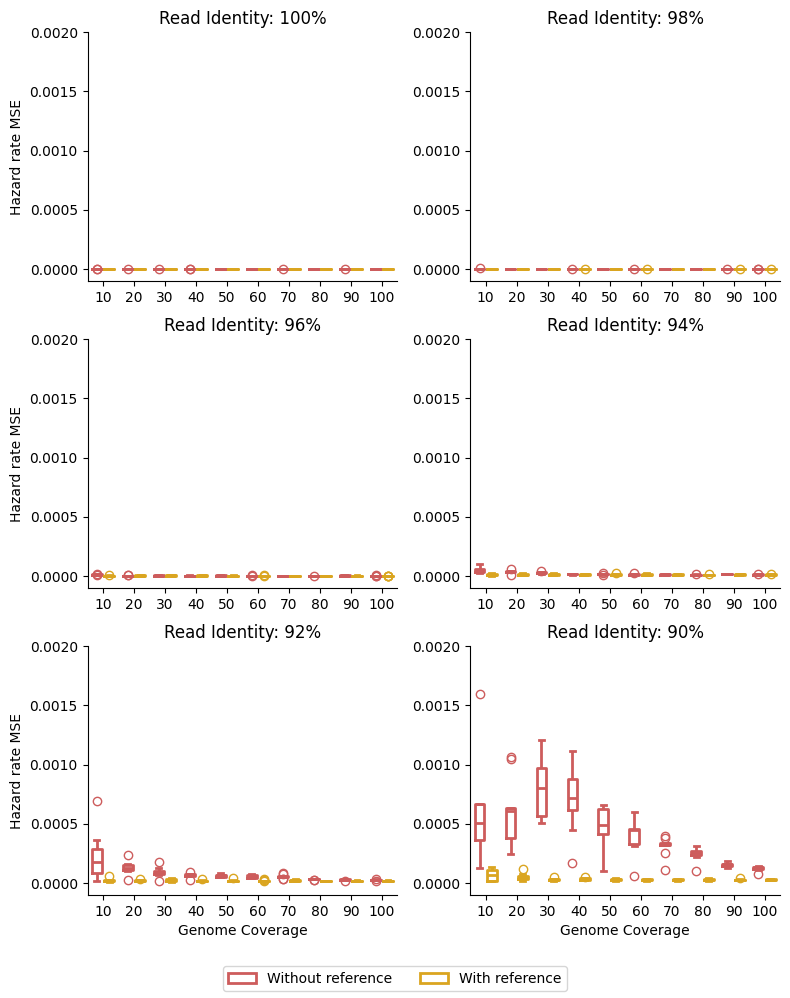

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten()

for idx, identity_value in enumerate(id):
    result_df_subset = result_df[result_df['identity'] == identity_value]
    sns.boxplot(
        data=result_df_subset, x="coverage", y="hazard_rate_mise", hue="with_reference",
        fill=False, gap=.2,
        linewidth=2,
        flierprops={"marker": "o"},
        palette=["indianred", "goldenrod"],
        ax=axes[idx]
    )
    
    axes[idx].set_title(f"Read Identity: {identity_value}%")
    if idx >= 4:
        axes[idx].set_xlabel("Genome Coverage")
    else:
        axes[idx].set_xlabel("")
    if idx % 2 == 0:
        axes[idx].set_ylabel("Hazard rate MSE")
    else:
        axes[idx].set_ylabel("")
    #axes[idx].set_ylim(max(-0.01, gt - 0.03), gt + 0.15)
    axes[idx].get_legend().remove()
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].set_ylim(-0.0001, 0.002)

    #axes[idx].set_yscale('log')
    #axes[idx].legend(title="Reference", loc="upper right")
plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(bottom=0.1)

# Adjust layout

plt.savefig("../../figures/simulated_data_all_coverage_hazard.pdf")
